## Importação de Bibliotecas

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

ARQUIVO = "/content/LitDigestFull.xlsx"

# pra corrgir grafias diferentes do mesmo estado e de total
NOMES_ESTADO = {
    "Dist Columbia": "District Of Columbia",
    "Dist. Of Columbia": "District Of Columbia",
    "Total": "Totals",
}

## Funções de Tratamento e Processamento de Dados

Neste bloco, criamos as funções auxiliares essenciais para carregar e limpar a base de dados da enquete e dos resultados históricos:
- **`para_numero`**: Converte strings de texto para valores numéricos, limpando e tratando adequadamente símbolos especiais (como o sinal de menos unicode e vírgulas).
- **`separar_blocos`**: Analisa e divide uma aba do Excel em sub-tabelas menores, detectando as colunas 100% vazias como fronteiras de separação.
- **`linhas_de_cabecalho`** e **`achatar_cabecalho`**: Identificam dinamicamente onde terminam os metadados das colunas e combinam de maneira lógica cabeçalhos de múltiplas linhas para gerar nomes de colunas inteligíveis.
- **`limpar_bloco`**: Aplica de ponta a ponta as rotinas de limpeza nos estados e dados numéricos para cada sub-tabela.

In [ ]:
#'-', '–' viram NaN; '−6,788' (menos unicode + milhar) vira -6788.
def para_numero(s: pd.Series) -> pd.Series:
    t = (s.astype(str).str.strip()
           .str.replace("\u2212", "-", regex=False)   # sinal de menos unicode
           .str.replace(",", "", regex=False))
    t = t.mask(t.isin(["-", "–", "nan", ""]))
    return pd.to_numeric(t, errors="coerce")

def eh_numero(v) -> bool:
    return pd.notna(para_numero(pd.Series([v])).iloc[0])

#Quebra a aba em blocos de colunas separados por colunas 100% vazias. Descarta colunas que só têm link (fonte da Wikipedia).
def separar_blocos(df: pd.DataFrame) -> list[pd.DataFrame]:
    df = df.loc[:, ~df.apply(lambda c: c.dropna().astype(str).str.startswith("http").all()
                             and c.notna().any())]
    vazias = df.isna().all()
    blocos, atual = [], []
    for col in df.columns:
        if vazias[col]:
            if atual:
                blocos.append(df[atual]); atual = []
        else:
            atual.append(col)
    if atual:
        blocos.append(df[atual])
    # para tratar bloco de 1 coluna só
    unidos = []
    for b in blocos:
        if b.shape[1] == 1 and unidos:
            unidos[-1] = pd.concat([unidos[-1], b], axis=1)
        else:
            unidos.append(b)
    return unidos

#Nº de linhas de cabeçalho = linhas antes da 1ª em que a maioria das células (tirando a 1ª coluna, que é o estado) é numérica.
def linhas_de_cabecalho(bloco: pd.DataFrame) -> int:
    for i, (_, lin) in enumerate(bloco.iterrows()):
        cel = lin.iloc[1:].dropna()
        if len(cel) and sum(eh_numero(v) for v in cel) / len(cel) >= 0.5:
            return i
    raise ValueError("inicio não encontrado")

#Cabeçalho de 1 ou 2 linhas -> nomes únicos. Linha de cima é propagada para a direita (efeito de célula mesclada).
def achatar_cabecalho(cab: pd.DataFrame) -> list[str]:
    cab = cab.copy()
    if len(cab) > 1:
        cab.iloc[0] = cab.iloc[0].ffill()
    nomes = []
    for col in cab.columns:
        partes = [str(v).strip() for v in cab[col] if pd.notna(v)]
        partes = list(dict.fromkeys(partes))          # remove repetição
        nomes.append(" | ".join(partes) or "State")
    # desduplica oq estava duplicado ("%", "Electoral votes" repetem no bloco de resultados)
    vistos, final = {}, []
    for n in nomes:
        vistos[n] = vistos.get(n, 0) + 1
        final.append(n if vistos[n] == 1 else f"{n}_{vistos[n]}")
    return final

#Transforma um bloco bruto em uma tabela limpa com uma linha por estado.
def limpar_bloco(bloco: pd.DataFrame) -> pd.DataFrame:
    n = linhas_de_cabecalho(bloco)
    dados = bloco.iloc[n:].copy()
    dados.columns = achatar_cabecalho(bloco.iloc[:n])
    dados = dados.dropna(how="all")

    estado = dados.columns[0]
    dados[estado] = (dados[estado].astype(str).str.strip()
                     .str.replace(r"[\s.:]+$", "", regex=True).str.title()
                     .replace({"Nan": np.nan}))
    dados[estado] = dados[estado].replace(NOMES_ESTADO)
    # linha de total sem rótulo (ex.: 1924) -> 'Totals'
    dados[estado] = dados[estado].fillna("Totals")
    dados = dados.rename(columns={estado: "estado"})

    for c in dados.columns[1:]:
        conv = para_numero(dados[c])
        if conv.notna().sum() >= 0.5 * dados[c].notna().sum():
            dados[c] = conv
    dados["eh_total"] = dados["estado"].str.lower().isin(["totals", "total"])
    return dados.reset_index(drop=True)

def classificar(df: pd.DataFrame) -> str:
    return "resultado_oficial" if any("Margin" in c for c in df.columns) else "enquete"

## Leitura e Organização dos Dados Brutos

Neste bloco, o código faz a leitura das abas de 1932 e 1936 do arquivo Excel. Para cada aba, ele divide a planilha em blocos menores de dados (separados por colunas vazias), insere a coluna com os nomes dos estados onde necessário, aplica as funções de limpeza definidas anteriormente e guarda os blocos limpos em um dicionário (`resultado`), classificando-os entre enquetes e resultados oficiais.

In [ ]:
abas = pd.read_excel(ARQUIVO, sheet_name=["1932", "1936"], header=None)
resultado = {}   # {(ano, tipo, i): DataFrame}
for ano, bruto in abas.items():
    col_estado = bruto[[bruto.columns[0]]]      # coluna de estados da enquete
    for i, bloco in enumerate(separar_blocos(bruto)):
        # os sub-blocos da enquete não têm a coluna de estado, então estou reaproveitando a do começo da planilha que separei em cima
        primeira = bloco.iloc[3:, 0].dropna()
        if len(primeira) and primeira.map(eh_numero).mean() > 0.5:
            bloco = pd.concat([col_estado, bloco], axis=1)
        df = limpar_bloco(bloco)
        df.insert(0, "ano", int(ano))
        resultado[(int(ano), classificar(df), i)] = df

## Verificação das Dimensões dos Dados

Neste bloco, o código itera sobre o dicionário `resultado` (onde os dados limpos foram armazenados) e imprime as suas chaves — contendo o ano, tipo de bloco (enquete ou oficial) e índice — juntamente com as dimensões (`shape`, ou seja, o número de linhas e colunas) de cada DataFrame. Isso serve como uma rápida validação para checar se a extração e divisão das abas ocorreu corretamente.

In [ ]:
for k, df in resultado.items():
    print(k, df.shape)

(1932, 'enquete', 0) (51, 9)
(1932, 'enquete', 1) (51, 8)
(1932, 'enquete', 2) (51, 11)
(1932, 'resultado_oficial', 3) (49, 19)
(1936, 'enquete', 0) (50, 11)
(1936, 'enquete', 1) (50, 10)
(1936, 'enquete', 2) (50, 10)
(1936, 'enquete', 3) (50, 10)
(1936, 'resultado_oficial', 4) (49, 23)


## Consolidação dos Resultados Oficiais

Neste bloco, o código filtra o dicionário para extrair apenas os dados referentes ao `resultado_oficial` de cada ano (1932 e 1936). Ele percorre as colunas das planilhas para reestruturar as informações em formato longo (*tidy data*), mapeando cada candidato com seus respectivos votos (absolutos e percentuais) e votos eleitorais por estado, removendo ao final as linhas sem dados de votação.

In [ ]:
longos = []
for (ano, tipo, _), df in resultado.items():
    if tipo != "resultado_oficial": #Filtra só os blocos oficiais
        continue
    cols = list(df.columns)
    for j, c in enumerate(cols):
        #Passa reto as colunas que não são de candidatos
        if c.startswith("%") or c.startswith("Electoral") or c in ("ano", "estado", "eh_total"):
            continue
        if not c.startswith(("Margin", "State")) and j + 1 < len(cols) and cols[j + 1].startswith("%"):
            ev = cols[j - 1] if cols[j - 1].startswith("Electoral") else None
            longos.append(pd.DataFrame({
                "ano": df["ano"], "estado": df["estado"], "eh_total": df["eh_total"],
                "candidato": c,
                "votos": para_numero(df[c]),
                "pct": para_numero(df[cols[j + 1]]), # Aqui é quantidade de votos populares
                "votos_eleitorais": para_numero(df[ev]) if ev else np.nan, #% de votos no estado
            }))
oficial = pd.concat(longos, ignore_index=True).dropna(subset=["votos"])

## Visualização do DataFrame Consolidado

Neste bloco, o código exibe as primeiras linhas do DataFrame final `oficial`. Esta tabela consolidada em formato longo (*tidy*) contém os dados estruturados de votação real para cada estado, ano e candidato, permitindo conferir e validar os resultados finais limpos antes das análises seguintes.

In [ ]:
oficial.head(1000)

,ano,estado,eh_total,candidato,votos,pct,votos_eleitorais
0,1932,Alabama,False,Roosevelt,207910.0,84.74,11.0
1,1932,Arizona,False,Roosevelt,79264.0,67.03,3.0
2,1932,Arkansas,False,Roosevelt,189602.0,85.96,9.0
3,1932,California,False,Roosevelt,1324157.0,58.39,22.0
4,1932,Colorado,False,Roosevelt,250877.0,54.81,6.0
...,...,...,...,...,...,...,...
436,1936,Washington,False,Other,4908.0,0.71,NaN
437,1936,West Virginia,False,Other,1173.0,0.14,NaN
438,1936,Wisconsin,False,Other,3825.0,0.30,NaN
439,1936,Wyoming,False,Other,166.0,0.16,NaN


## Estruturação dos Dados da Enquete de 1936

Neste bloco, iniciamos a Análise Exploratória de Dados (EDA). O código extrai as intenções de voto para os candidatos Landon (Republicano), Roosevelt (Democrata) e Lemke (Terceiro partido) diretamente dos sub-blocos de enquete de 1936. Adicionalmente, recupera o histórico autodeclarado de como os entrevistados votaram em 1932 (repartido entre Republicanos e Democratas), calcula as métricas percentuais básicas para cada estado e exibe as primeiras linhas do DataFrame unificado resultante.

In [ ]:
enq = {i: resultado[(1936, "enquete", i)].set_index("estado") for i in range(4)}

def col(df, prefixo):
    #Acha a coluna pelo início do nome (os nomes achatados são longos).
    return df[[c for c in df.columns if c.startswith(prefixo)][0]]

enquete = pd.DataFrame({
    "landon":    col(enq[0], "Landon"),
    "roosevelt": col(enq[1], "Roosevelt"),
    "lemke":     col(enq[2], "Lemke"),
    "total":     col(enq[3], "Grand Total"),
})
for partido in ["Rep.", "Dem."]:
    enquete["v32_" + partido[:3].lower()] = sum(
        col(enq[i], "How did they vote in 1932? | " + partido) for i in range(3))

enquete = enquete.drop(index=["Totals", "State Unknown"], errors="ignore")
enquete["enq_fdr_36"]    = 100 * enquete.roosevelt / enquete.total
enquete["enq_hoover_32"] = 100 * enquete.v32_rep / (enquete.v32_rep + enquete.v32_dem)
enquete.head(1000)

,landon,roosevelt,lemke,total,v32_rep,v32_dem,enq_fdr_36,enq_hoover_32
estado,,,,,,,,
Alabama,3060,10082,68,13273,1594,9877,75.958713,13.895911
Arizona,2337,1975,104,4476,1701,2254,44.124218,43.008850
Arkansas,2724,7608,138,10540,1580,7706,72.182163,17.014861
California,89516,77245,4977,173935,82145,72280,44.410268,53.194107
Colorado,15949,10025,579,26786,13755,10303,37.426267,57.174329
Connecticut,28809,13413,1489,44151,25768,13495,30.379833,65.629218
Delaware,2918,2048,35,5028,2852,1692,40.731901,62.764085
Florida,6087,8620,195,15021,3793,9091,57.386326,29.439615
Georgia,3948,12915,35,16999,1621,12217,75.975057,11.714121


## Cruzamento de Dados e Cálculo de Viés

Neste bloco, o código filtra o DataFrame `oficial` para separar apenas os votos reais dos estados (removendo as linhas de totais) e monta um novo DataFrame `real` com os dados oficiais de Roosevelt e Hoover. Em seguida, realiza um cruzamento (`join`) desses dados reais com as previsões da `enquete` de 1936 e calcula duas métricas importantes para cada estado:
- **`erro_36`**: A diferença entre a previsão da enquete para Roosevelt e o seu resultado real em 1936.
- **`vies_32`**: A diferença entre a proporção de eleitores na amostra que declararam ter votado em Hoover em 1932 e o resultado oficial que Hoover de fato teve naquela eleição.

In [ ]:
of = oficial[~oficial.eh_total] #resultado oficial sem as linhas de total

#Devolve um campo de candidato em um ano, indexado por estado
def serie(ano, cand, campo="pct"):
    return of.query("ano == @ano and candidato == @cand").set_index("estado")[campo]

real = pd.DataFrame({
    "real_fdr_36":    serie(1936, "Roosevelt"),
    "real_fdr_32":    serie(1932, "Roosevelt"),
    "real_hoover_32": serie(1932, "Hoover"),
    "ev_36":          serie(1936, "Roosevelt", "votos_eleitorais"),
})

# Checagem do join: estados presentes de um lado e ausentes do outro
print("Sem par no join:", set(enquete.index) ^ set(real.index))

estados = enquete.join(real, how="inner")
estados["erro_36"] = estados.enq_fdr_36 - estados.real_fdr_36
estados["vies_32"] = estados.enq_hoover_32 - estados.real_hoover_32
print(estados.shape)

Sem par no join: set()
(48, 14)


## Análise Estatística do Erro e do Viés

Neste bloco, o código utiliza o método `.describe()` para gerar um resumo estatístico (média, desvio padrão, mínimo, quartis e máximo) dos resultados calculados. A análise foca em quatro variáveis fundamentais por estado:
- **`enq_fdr_36`**: Percentual de votos para Roosevelt previsto pela enquete de 1936.
- **`real_fdr_36`**: Votação real oficial que Roosevelt obteve em 1936.
- **`erro_36`**: O tamanho do erro da previsão da enquete de 1936 (em pontos percentuais).
- **`vies_32`**: O viés de amostragem estimado com base na votação autodeclarada de 1932 comparada com a real.

In [ ]:
estados[["enq_fdr_36", "real_fdr_36", "erro_36", "vies_32"]].describe().round(2)

,enq_fdr_36,real_fdr_36,erro_36,vies_32
count,48.00,48.00,48.00,48.00
mean,46.01,64.73,-18.72,10.59
std,16.31,12.69,7.07,7.28
min,21.67,41.52,-29.55,-7.29
25%,35.86,56.82,-24.80,4.72
50%,41.31,61.30,-19.07,12.42
75%,54.20,69.47,-13.87,15.81
max,86.71,98.57,-1.15,24.40


## Comparação de Estados Vencidos por Roosevelt

Neste bloco, o código realiza uma comparação rápida e direta do desempenho geral do candidato Franklin D. Roosevelt (FDR) sob duas perspectivas:
- A quantidade de estados que a **enquete de 1936** previu que ele venceria (ou seja, estados onde a estimativa de votos para ele ficou acima de 50%).
- A quantidade de estados que ele **realmente venceu** na eleição oficial de 1936.

Essa contagem evidencia o erro drástico de previsão cometido pela revista, que apontou vitória em apenas 15 estados, quando na realidade ele venceu em 45.

In [ ]:
print("Estados com FDR vencedor — enquete:", (estados.enq_fdr_36 > 50).sum(),
      "| real:", (estados.real_fdr_36 > 50).sum())

Estados com FDR vencedor — enquete: 15 | real: 45


## Dispersão: Previsão da Enquete vs. Resultado Real

Neste bloco, criamos um gráfico de dispersão (*scatter plot*) que compara visualmente o percentual de votos previsto para Roosevelt por estado pela enquete (eixo X) com o percentual real oficial que ele obteve (eixo Y). A linha tracejada representa uma "previsão perfeita". Como quase todos os pontos estão visivelmente acima dela, fica nítido que a enquete subestimou sistematicamente a votação de Roosevelt em praticamente todos os estados americanos.

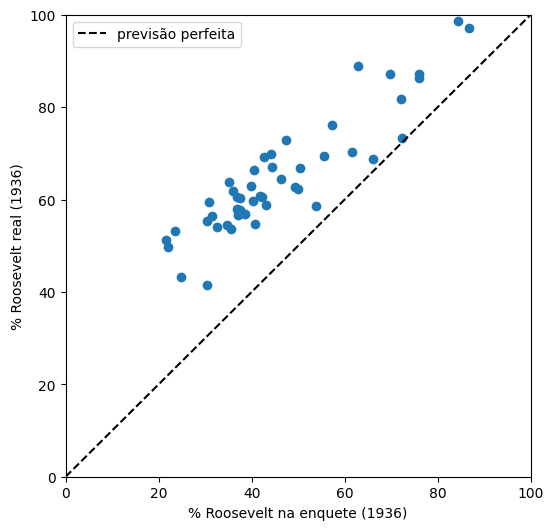

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(estados.enq_fdr_36, estados.real_fdr_36)
ax.plot([0, 100], [0, 100], "k--", label="previsão perfeita")
ax.set_xlabel("% Roosevelt na enquete (1936)")
ax.set_ylabel("% Roosevelt real (1936)")
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.legend()
plt.show()

## Distribuição do Viés de Amostragem de 1932

Neste bloco, plotamos um histograma para visualizar a distribuição do viés de amostragem por estado calculado para a eleição anterior (1932). A linha tracejada preta marca o ponto zero (sem viés). A forte concentração de estados à direita do zero revela graficamente o claro viés republicano da enquete da Literary Digest, que capturou uma proporção sistematicamente maior de eleitores declarados do Hoover do que o registrado nas urnas em 1932.

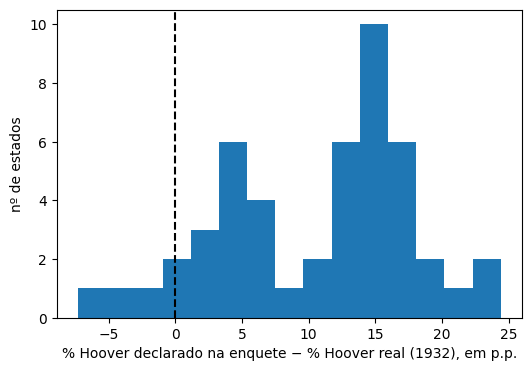

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(estados.vies_32, bins=15)
ax.axvline(0, color="k", ls="--")
ax.set_xlabel("% Hoover declarado na enquete − % Hoover real (1932), em p.p.")
ax.set_ylabel("nº de estados")
plt.show()

## Correlação entre Viés de Amostragem (1932) e Erro de Previsão (1936)

Neste bloco, cruzamos os dados históricos criando um gráfico de dispersão que relaciona diretamente o viés medido na amostra de 1932 com o erro observado na enquete de 1936 por estado. Calculamos também o coeficiente de correlação linear (Pearson). A fortíssima correlação negativa de -0,9 indica que quanto maior o viés conservador demonstrado pelo estado em 1932, maior e mais acentuado foi o erro de subestimação dos votos de Roosevelt em 1936, comprovando o caráter estrutural e persistente do viés de amostragem da publicação.

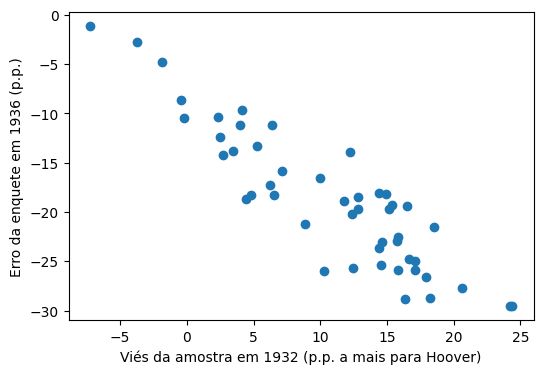

Correlação: -0.9


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(estados.vies_32, estados.erro_36)
ax.set_xlabel("Viés da amostra em 1932 (p.p. a mais para Hoover)")
ax.set_ylabel("Erro da enquete em 1936 (p.p.)")
plt.show()
print("Correlação:", round(estados[["vies_32", "erro_36"]].corr().iloc[0, 1], 2))

## Modelagem Preditiva e Ajustes de Regressão

Neste bloco, começamos a explorar soluções matemáticas para corrigir o viés histórico da enquete. Definimos a nossa variável alvo $Y$ como o resultado real de Roosevelt em 1936 e preparamos um DataFrame de previsões para comparar diferentes abordagens:
1. **`enquete_crua`**: A previsão sem nenhuma correção.
2. **`baseline_1932`**: Uma linha de base simples que apenas assume que o resultado de 1936 seria idêntico ao de 1932.
3. **`reg_simples`**: Ajuste de uma regressão linear simples usando apenas a intenção de voto da enquete de 1936.
4. **`reg_ancora_32`**: Um modelo de regressão linear múltipla que utiliza tanto a intenção de voto de 1936 quanto o resultado real da eleição de 1932 como âncora histórica.

Para avaliar o desempenho realista dos modelos de regressão, aplicamos a técnica de validação cruzada *Leave-One-Out* (LOOCV).

In [ ]:
y = estados["real_fdr_36"] #% Real do Roossevel em 36
previsoes = pd.DataFrame(index=estados.index) #Uma coluna por método

previsoes["enquete_crua"] = estados["enq_fdr_36"]
previsoes["baseline_1932"] = estados["real_fdr_32"]

#Variaveis explicativas de cada regressão
modelos = {
    "reg_simples":   ["enq_fdr_36"],
    "reg_ancora_32": ["enq_fdr_36", "real_fdr_32"],
}

# Leave-one-out: cada estado é previsto por um modelo treinado nos outros 47, para que o modelo nunca veja a resposta do estado que está prevendo
for nome, X_cols in modelos.items():
    previsoes[nome] = cross_val_predict(LinearRegression(), estados[X_cols], y, cv=LeaveOneOut())

## Estratégia de Reponderação de Eleitores baseada em 1932

Neste bloco, aplicamos um método alternativo de correção de viés através da reponderação da amostra da enquete.

O processo funciona da seguinte forma:
1. **Taxa de Transição Inter-Partidária**: Calculamos, dentro da própria enquete de 1936, a intenção de voto para Roosevelt de forma segmentada de acordo com o voto autodeclarado do participante em 1932 (separando a preferência de quem disse ter votado em Democratas ou Republicanos na eleição anterior).
2. **Peso Real dos Eleitores (1932)**: Calculamos o peso populacional correto de Democratas e Republicanos usando o resultado oficial real da eleição de 1932.
3. **Média Ponderada Corrigida**: Combinamos as taxas de transição estimadas pela enquete usando as proporções corretas (reais) de eleitores da eleição anterior como pesos, gerando a previsão corrigida `reponderacao_32`.

In [ ]:
def grupo(partido):
    p = "How did they vote in 1932? | " + partido
    g = pd.DataFrame({cand: col(enq[i], p) for i, cand in enumerate(["landon", "roosevelt", "lemke"])})
    #Remove linhas que não são estadose alinha na ordem da tabela de estados
    return g.drop(index=["Totals", "State Unknown"], errors="ignore").loc[estados.index]

rep, dem = grupo("Rep."), grupo("Dem.")
fdr_entre_rep = rep.roosevelt / rep.sum(axis=1)
fdr_entre_dem = dem.roosevelt / dem.sum(axis=1)

#peso real do grupo democrata em 32
peso_dem = estados.real_fdr_32 / (estados.real_fdr_32 + estados.real_hoover_32)
#média ponderada dos grupos
previsoes["reponderacao_32"] = 100 * (peso_dem * fdr_entre_dem + (1 - peso_dem) * fdr_entre_rep)

## Avaliação de Desempenho e Comparação dos Modelos

Neste bloco, definimos uma função para calcular e comparar o desempenho de cada uma das abordagens de previsão que criamos. Para cada cenário analisado, extraímos métricas cruciais:
- **`MAE (p.p.)`**: O Erro Absoluto Médio em pontos percentuais (indica o desvio médio geral das estimativas).
- **`Viés médio (p.p.)`**: Mostra se o modelo tende a subestimar ou superestimar de forma sistemática.
- **`Estados c/ vencedor certo`**: O número total de estados (de um total de 48) onde o modelo previu corretamente o vencedor da eleição.
- **`Votos eleitorais certos`**: O somatório de votos no Colégio Eleitoral dos estados cuja previsão de vitória foi acertada.

Os resultados consolidados na tabela nos permitem identificar com precisão qual técnica estatística obteve o melhor desempenho corretivo.

In [ ]:
def metricas(prev):
    erro = prev - y
    return pd.Series({
        "MAE (p.p.)":            erro.abs().mean(),
        "Viés médio (p.p.)":     erro.mean(),
        "Estados c/ vencedor certo": ((prev > 50) == (y > 50)).sum(),
        "Votos eleitorais certos":   estados.ev_36[(prev > 50) == (y > 50)].sum(),
    })

#aplica as métricas a cada cada método e transpõe: uma linha por metodo
tabela = previsoes.apply(metricas).T.round(2)
tabela

,MAE (p.p.),Viés médio (p.p.),Estados c/ vencedor certo,Votos eleitorais certos
enquete_crua,18.72,-18.72,18.0,170.0
baseline_1932,4.29,-1.96,43.0,442.0
reg_simples,4.31,-0.02,44.0,502.0
reg_ancora_32,3.43,0.01,47.0,526.0
reponderacao_32,13.09,-13.09,24.0,210.0


## Comparação Visual do Erro Médio (MAE) por Modelo

Neste bloco, geramos um gráfico de barras horizontais para comparar visualmente o Erro Absoluto Médio (MAE) em pontos percentuais de cada modelo construído. A visualização facilita a identificação rápida de que o modelo de regressão linear que utiliza o resultado real de 1932 como âncora histórica (`reg_ancora_32`) foi o mais preciso, apresentando o menor erro médio geral, enquanto a enquete crua original (`enquete_crua`) apresenta o pior desempenho disparado.

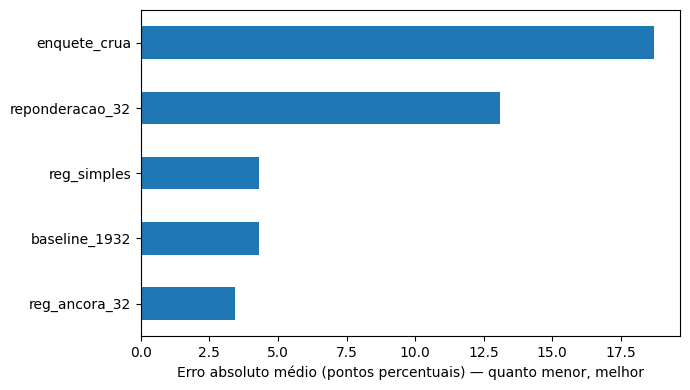

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
tabela["MAE (p.p.)"].sort_values().plot.barh(ax=ax)
ax.set_xlabel("Erro absoluto médio (pontos percentuais) — quanto menor, melhor")
plt.tight_layout(); plt.show()

## Coeficientes do Modelo de Regressão Linear Múltipla

Neste bloco, ajustamos o nosso melhor modelo estatístico (`reg_ancora_32`) sobre todos os estados para interpretar os seus coeficientes finais e o intercepto. A equação estimada nos ajuda a entender o peso relativo de cada variável na correção:
- O coeficiente de **`enq_fdr_36`** mostra a importância dada à intenção de voto atual da enquete.
- O coeficiente de **`real_fdr_32`** quantifica a influência do resultado histórico real de 1932 como um fator de ajuste de viés.
- O **intercepto** representa o patamar básico de votação ajustado pelo modelo.

In [ ]:
# aqui tem os coefs
m = LinearRegression().fit(estados[modelos["reg_ancora_32"]], y)
print(dict(zip(modelos["reg_ancora_32"], m.coef_.round(3))), "intercepto:", round(m.intercept_, 2))

{'enq_fdr_36': np.float64(0.324), 'real_fdr_32': np.float64(0.513)} intercepto: 17.6
